In [91]:
!pip -q install -U datasets scikit-learn

In [92]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from datasets import load_dataset

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [93]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [94]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [95]:
import datasets
print(datasets.__version__)

5.0.1


In [96]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    "AlvaroVasquezAI/Animal_Image_Classification_Dataset",
    repo_type="dataset"
)

print(files)

['.gitattributes', 'README.md', 'cats_dogs_snakes.zip']


In [97]:
from huggingface_hub import hf_hub_download

zip_path = hf_hub_download(
    repo_id="AlvaroVasquezAI/Animal_Image_Classification_Dataset",
    filename="cats_dogs_snakes.zip",
    repo_type="dataset"
)

print(zip_path)

/root/.cache/huggingface/hub/datasets--AlvaroVasquezAI--Animal_Image_Classification_Dataset/snapshots/79b23706ea01d1cfecc7470fbf5cd2cd5a665165/cats_dogs_snakes.zip


In [98]:
import zipfile

extract_dir = "/content/animal_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted.")

Dataset extracted.


In [99]:
import os

for root, dirs, files in os.walk(extract_dir):
    print(root, "->", len(files), "files")

/content/animal_dataset -> 0 files
/content/animal_dataset/dataset -> 0 files
/content/animal_dataset/dataset/dogs -> 1000 files
/content/animal_dataset/dataset/cats -> 1000 files
/content/animal_dataset/dataset/snakes -> 1000 files


In [100]:
dataset = load_dataset(
    "imagefolder",
    data_dir="/content/animal_dataset/dataset"
)

print(dataset)

Resolving data files:   0%|          | 0/3000 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 3000
    })
})


In [101]:
train_hf = dataset["train"]
train_hf

Dataset({
    features: ['image', 'label'],
    num_rows: 3000
})

In [102]:
print("Number of images:", len(train_hf))
print("Columns:", train_hf.column_names)
print("Features:", train_hf.features)

Number of images: 3000
Columns: ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cats', 'dogs', 'snakes'])}


In [103]:
print(train_hf[0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7E33CE0F9350>, 'label': 0}


In [104]:
label_names = train_hf.features["label"].names
label_names

['cats', 'dogs', 'snakes']

In [105]:
print("Label mapping:")

for idx, name in enumerate(label_names):
    print(idx, "->", name)

Label mapping:
0 -> cats
1 -> dogs
2 -> snakes


Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (256, 256)
Image mode: RGB
Label: 0
Class: cats


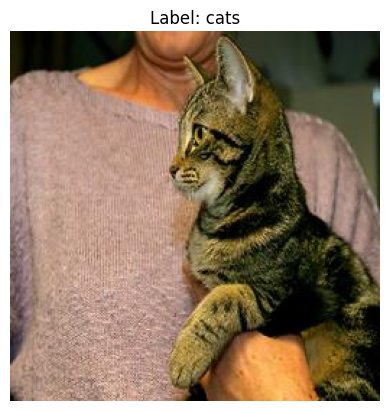

In [106]:
sample = train_hf[0]

image = sample["image"]
label = sample["label"]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)
print("Class:", label_names[label])

plt.imshow(image)
plt.title(f"Label: {label_names[label]}")
plt.axis("off")
plt.show()

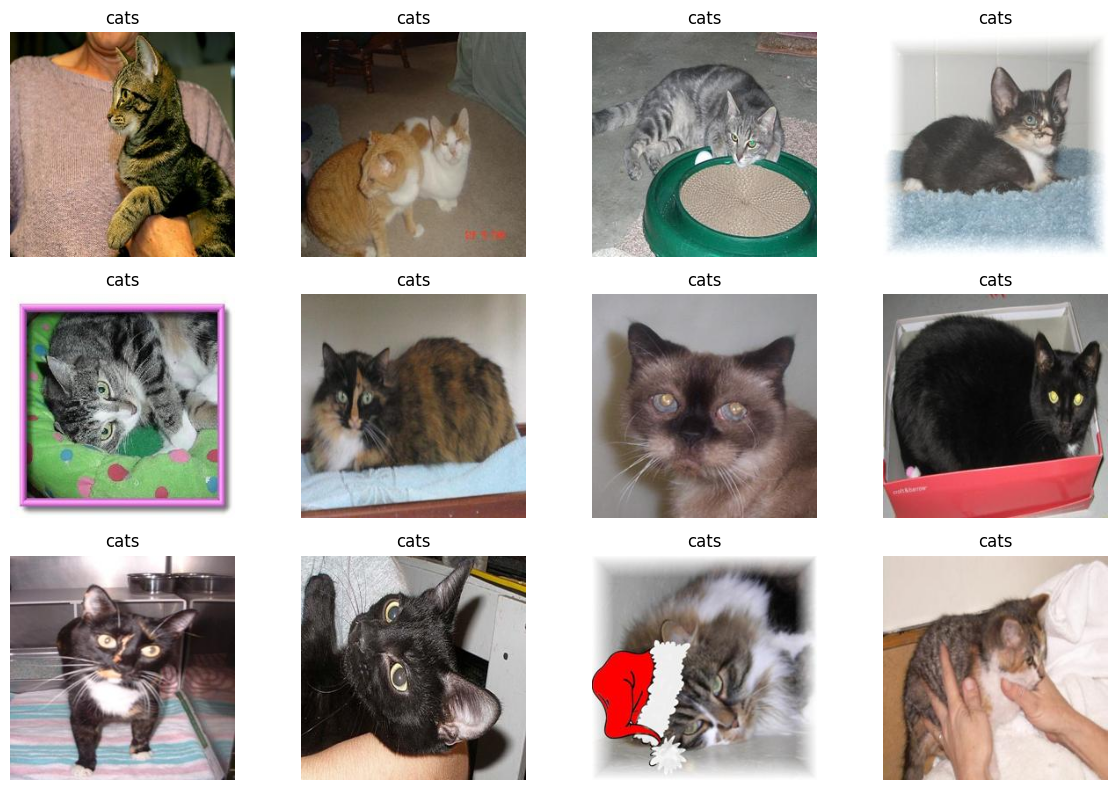

In [107]:
plt.figure(figsize=(12, 8))

for i in range(12):
    sample = train_hf[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(sample["image"])
    plt.title(label_names[sample["label"]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [108]:
from collections import Counter

label_counts = Counter(train_hf["label"])

for label_id, count in sorted(label_counts.items()):
    print(
        f"{label_names[label_id]}: {count}"
    )

cats: 1000
dogs: 1000
snakes: 1000


In [109]:
train_val = train_hf.train_test_split(
    test_size=0.30,
    seed=SEED,
    stratify_by_column="label"
)

train_hf = train_val["train"]
temp_hf = train_val["test"]

val_test = temp_hf.train_test_split(
    test_size=0.50,
    seed=SEED,
    stratify_by_column="label"
)

val_hf = val_test["train"]
test_hf = val_test["test"]

print("Train:", len(train_hf))
print("Validation:", len(val_hf))
print("Test:", len(test_hf))

Train: 2100
Validation: 450
Test: 450


In [110]:
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [111]:
eval_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.CenterCrop(IMG_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [112]:
class AnimalDataset(Dataset):

    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]

        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [113]:
train_dataset = AnimalDataset(
    train_hf,
    transform=train_transform
)

val_dataset = AnimalDataset(
    val_hf,
    transform=eval_transform
)

test_dataset = AnimalDataset(
    test_hf,
    transform=eval_transform
)

In [117]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2100
450
450


In [122]:
image, label = train_dataset[0]

print("Tensor shape:", image.shape)
print("Label:", label)

Tensor shape: torch.Size([3, 224, 224])
Label: 2


In [119]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [123]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [124]:
num_classes = len(label_names)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=3, bias=True)


In [125]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [126]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 1539
Total parameters: 11178051


In [127]:
criterion = nn.CrossEntropyLoss()

In [128]:
optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [129]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [130]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [131]:
NUM_EPOCHS_STAGE_1 = 3

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_state = None

for epoch in range(NUM_EPOCHS_STAGE_1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS_STAGE_1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 0.3443 | Train Acc: 0.8957 | Val Loss: 0.1331 | Val Acc: 0.9644
Epoch 2/3 | Train Loss: 0.1368 | Train Acc: 0.9619 | Val Loss: 0.1256 | Val Acc: 0.9578
Epoch 3/3 | Train Loss: 0.1016 | Train Acc: 0.9714 | Val Loss: 0.0926 | Val Acc: 0.9711


In [132]:
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [133]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [134]:
model.load_state_dict(best_state)

<All keys matched successfully>

In [135]:
NUM_EPOCHS_STAGE_2 = 7

for epoch in range(NUM_EPOCHS_STAGE_2):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Fine-tune Epoch {epoch + 1}/{NUM_EPOCHS_STAGE_2} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Fine-tune Epoch 1/7 | Train Loss: 0.0845 | Train Acc: 0.9695 | Val Loss: 0.0816 | Val Acc: 0.9800
Fine-tune Epoch 2/7 | Train Loss: 0.0330 | Train Acc: 0.9910 | Val Loss: 0.0841 | Val Acc: 0.9822
Fine-tune Epoch 3/7 | Train Loss: 0.0251 | Train Acc: 0.9914 | Val Loss: 0.0720 | Val Acc: 0.9800
Fine-tune Epoch 4/7 | Train Loss: 0.0169 | Train Acc: 0.9938 | Val Loss: 0.0694 | Val Acc: 0.9822
Fine-tune Epoch 5/7 | Train Loss: 0.0219 | Train Acc: 0.9924 | Val Loss: 0.0747 | Val Acc: 0.9778
Fine-tune Epoch 6/7 | Train Loss: 0.0171 | Train Acc: 0.9948 | Val Loss: 0.0750 | Val Acc: 0.9867
Fine-tune Epoch 7/7 | Train Loss: 0.0120 | Train Acc: 0.9957 | Val Loss: 0.0662 | Val Acc: 0.9889


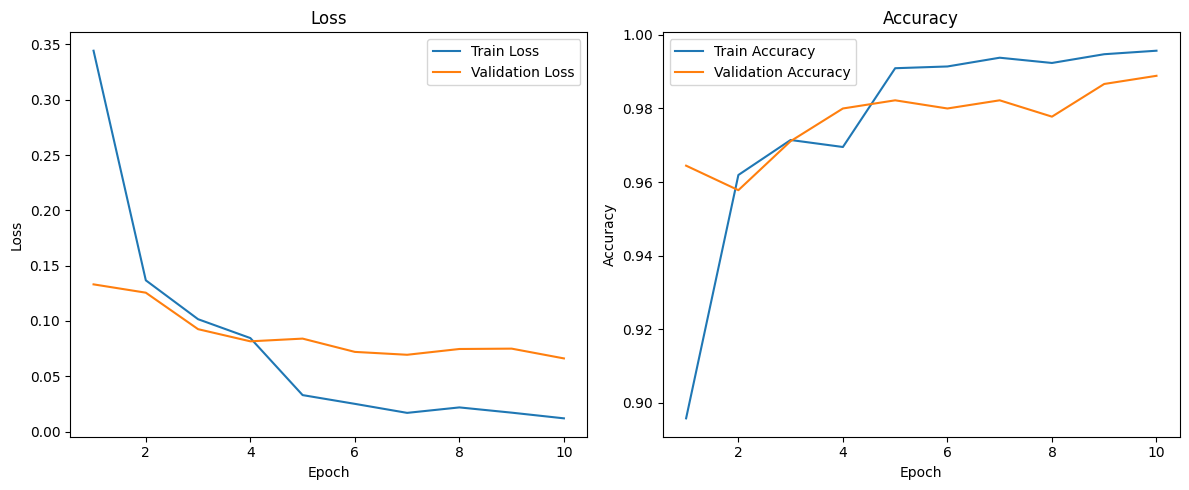

In [136]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [137]:
model.load_state_dict(best_state)

<All keys matched successfully>

In [138]:
test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0605
Test Accuracy: 0.9844


In [139]:
all_labels = []
all_predictions = []

model.eval()

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

In [140]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_names,
        digits=4
    )
)

              precision    recall  f1-score   support

        cats     0.9799    0.9733    0.9766       150
        dogs     0.9735    0.9800    0.9767       150
      snakes     1.0000    1.0000    1.0000       150

    accuracy                         0.9844       450
   macro avg     0.9845    0.9844    0.9844       450
weighted avg     0.9845    0.9844    0.9844       450



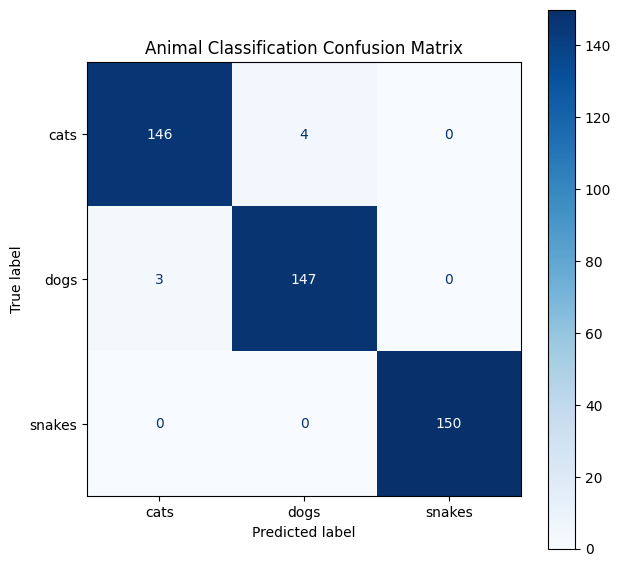

In [141]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Animal Classification Confusion Matrix")
plt.show()

In [142]:
wrong_indices = np.where(
    all_labels != all_predictions
)[0]

print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 7


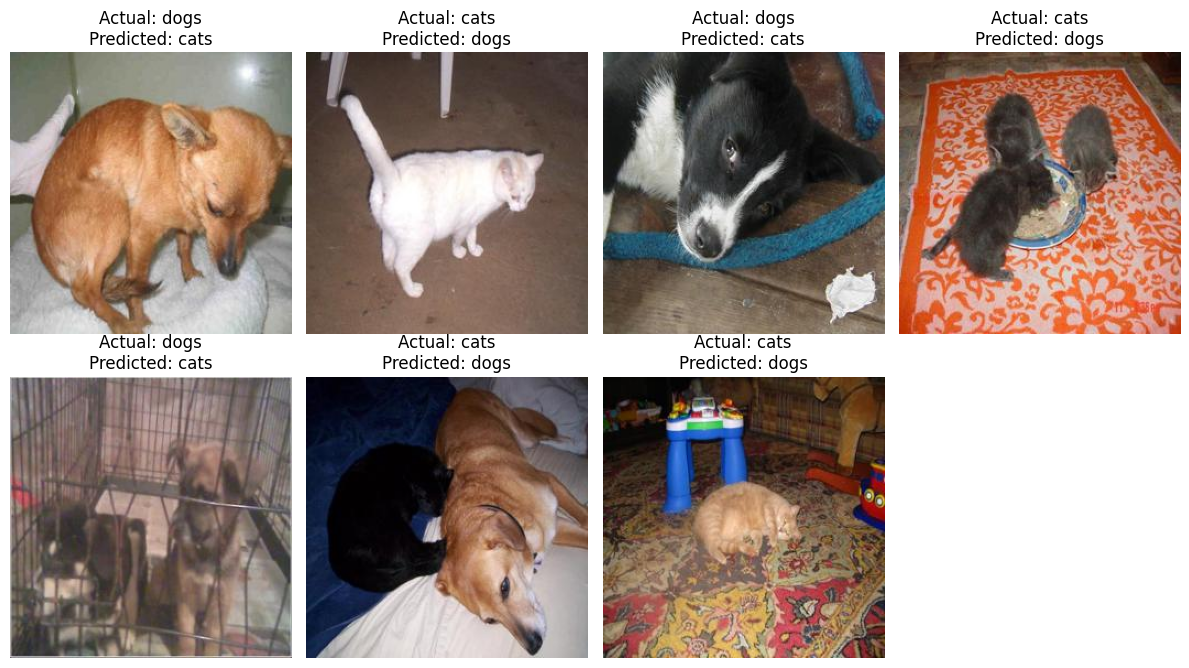

In [143]:
plt.figure(figsize=(12, 10))

num_to_show = min(12, len(wrong_indices))

for i in range(num_to_show):

    idx = wrong_indices[i]

    image, actual_label = test_hf[idx]["image"], test_hf[idx]["label"]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {label_names[actual_label]}\n"
        f"Predicted: {label_names[all_predictions[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [144]:
all_probs = []

model.eval()

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        all_probs.append(
            probs.cpu()
        )

all_probs = torch.cat(all_probs).numpy()

In [145]:
all_probs[2]

array([2.0595775e-05, 9.9992347e-01, 5.5965804e-05], dtype=float32)

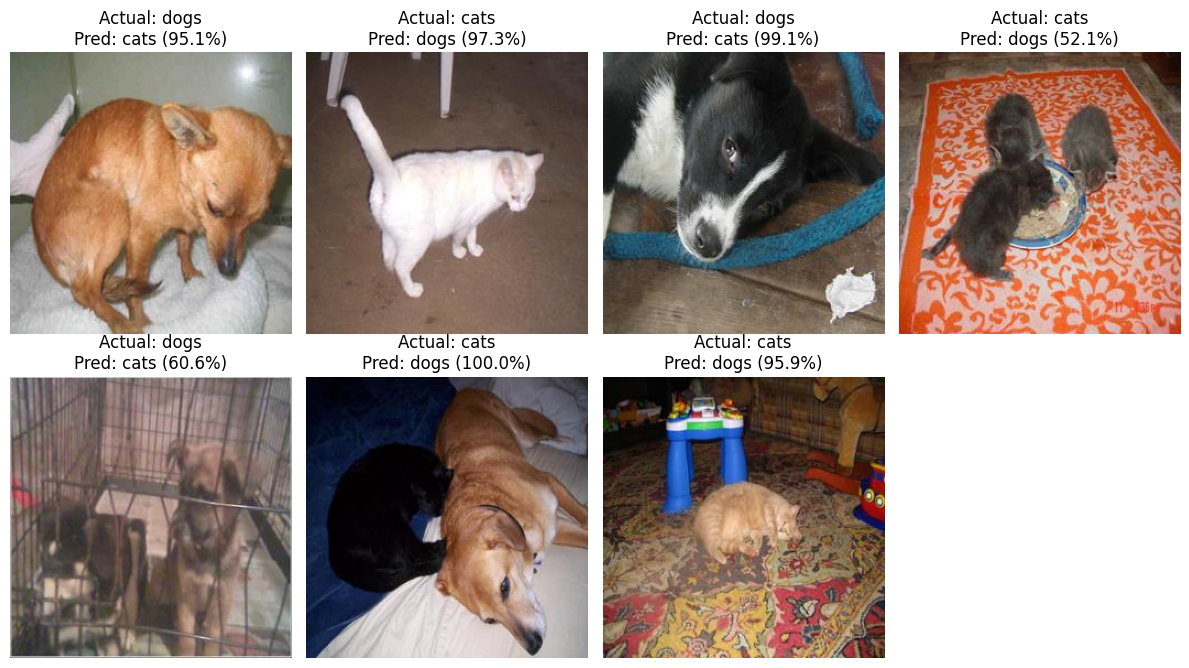

In [146]:
plt.figure(figsize=(12, 10))

num_to_show = min(12, len(wrong_indices))

for i in range(num_to_show):

    idx = wrong_indices[i]

    image = test_hf[idx]["image"]
    actual = label_names[all_labels[idx]]
    predicted_id = all_predictions[idx]
    predicted = label_names[predicted_id]
    confidence = all_probs[idx][predicted_id]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {predicted} ({confidence:.1%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [147]:
MODEL_PATH = "/content/best_resnet18_animals.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": label_names
    },
    MODEL_PATH
)

print("Saved to:", MODEL_PATH)

Saved to: /content/best_resnet18_animals.pth


In [148]:
weights = ResNet18_Weights.DEFAULT

loaded_model = resnet18(
    weights=None
)

loaded_model.fc = nn.Linear(
    loaded_model.fc.in_features,
    len(label_names)
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

loaded_model = loaded_model.to(device)
loaded_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [149]:
def predict_image(
    image,
    model,
    transform,
    class_names,
    device
):
    image = image.convert("RGB")

    tensor = transform(image)

    tensor = tensor.unsqueeze(0)

    tensor = tensor.to(device)

    model.eval()

    with torch.inference_mode():

        outputs = model(tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_class = probabilities.argmax(
            dim=1
        ).item()

    predicted_name = class_names[predicted_class]
    confidence = probabilities[
        0, predicted_class
    ].item()

    return predicted_name, confidence

In [151]:
from google.colab import files

uploaded = files.upload()

Saving New Species Cat For Animal Classification.avif to New Species Cat For Animal Classification.avif


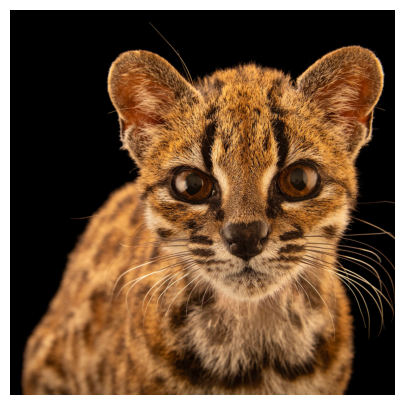

In [152]:
filename = next(iter(uploaded))

new_image = Image.open(filename)

plt.figure(figsize=(5, 5))
plt.imshow(new_image)
plt.axis("off")
plt.show()

In [153]:
predicted_class, confidence = predict_image(
    new_image,
    model,
    eval_transform,
    label_names,
    device
)

print(
    f"Prediction: {predicted_class}"
)

print(
    f"Confidence: {confidence:.2%}"
)

Prediction: cats
Confidence: 98.63%


In [154]:
def predict_with_probabilities(
    image,
    model,
    transform,
    class_names,
    device
):
    image = image.convert("RGB")

    tensor = transform(image)
    tensor = tensor.unsqueeze(0)
    tensor = tensor.to(device)

    model.eval()

    with torch.inference_mode():

        outputs = model(tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0]

    results = {
        class_names[i]: probabilities[i].item()
        for i in range(len(class_names))
    }

    return results

In [155]:
probabilities = predict_with_probabilities(
    new_image,
    model,
    eval_transform,
    label_names,
    device
)

for animal, probability in probabilities.items():
    print(
        f"{animal}: {probability:.2%}"
    )

cats: 98.63%
dogs: 0.04%
snakes: 1.33%
